# Ablation — Basic Quantization Design Study

This notebook analyzes the 48 W&B runs from the quantization design study.

The sweep covers:

| Factor | Values |
|---|---|
| Bitwidth | `8`, `4` |
| Granularity | `per_tensor`, `per_channel` |
| Symmetry | `symmetric`, `asymmetric` |
| Calibration | `uncalibrated`, `percentile` |
| Seeds | `1337`, `42`, `123` |

Total expected runs: `2 × 2 × 2 × 2 × 3 = 48`.

The goal is to measure how basic design choices affect final round-trip validation BPB and compressed model size.

## Setup

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import wandb

# Optional project styling, compatible with previous notebooks.
try:
    import importlib, utils
    importlib.reload(utils)
    from utils import apply_style, get_deep_palette
    apply_style(force=True)
    PALETTE = get_deep_palette()
except Exception:
    plt.rcParams.update({
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })
    PALETTE = [
        "#4C78A8", "#F58518", "#54A24B", "#E45756",
        "#72B7B2", "#B279A2", "#FF9DA6", "#9D755D"
    ]

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

BITS_ORDER = [8, 4]
GRAN_ORDER = ["per_tensor", "per_channel"]
SYM_ORDER = ["symmetric", "asymmetric"]
CAL_ORDER = ["uncalibrated", "percentile"]
SEED_ORDER = [1337, 42, 123]

DISPLAY_LABELS = {
    "per_tensor": "per-tensor",
    "per_channel": "per-channel",
    "symmetric": "symmetric",
    "asymmetric": "asymmetric",
    "uncalibrated": "uncalibrated",
    "percentile": "percentile-clipped",
}

OUT_DIR = Path("../notebook_outputs/quant_design")
OUT_DIR.mkdir(parents=True, exist_ok=True)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: ERROR Invalid API key: API key must have 40+ characters, has 36.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Log

## Download runs from W&B

This cell uses the W&B API and saves a raw CSV similar to the export snippet from W&B.

It filters runs whose display name matches:

```text
quant_design_<bits>_<granularity>_<symmetry>_<calibration>_seed<seed>
```


In [3]:
RUN_RE = re.compile(
    r"^quant_design_"
    r"(?P<bits>4|8)_"
    r"(?P<granularity>per_tensor|per_channel)_"
    r"(?P<symmetry>symmetric|asymmetric)_"
    r"(?P<calibration>uncalibrated|percentile)_"
    r"seed(?P<seed>1337|42|123)$"
)

expected_names = [
    f"quant_design_{bits}_{gran}_{sym}_{cal}_seed{seed}"
    for bits in BITS_ORDER
    for gran in GRAN_ORDER
    for sym in SYM_ORDER
    for cal in CAL_ORDER
    for seed in SEED_ORDER
]
expected_names = set(expected_names)

runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^quant_design_(4|8)_(per_tensor|per_channel)_(symmetric|asymmetric)_(uncalibrated|percentile)_seed(1337|42|123)$"}},
))

print(f"Fetched {len(runs)} matching W&B run objects before de-duplication")

summary_list, config_list, name_list, state_list, created_at_list, run_id_list = [], [], [], [], [], []
for run in runs:
    summary_list.append(run.summary._json_dict)
    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
    name_list.append(run.name)
    state_list.append(run.state)
    created_at_list.append(run.created_at)
    run_id_list.append(run.id)

runs_df = pd.DataFrame({
    "summary": summary_list,
    "config": config_list,
    "name": name_list,
    "state": state_list,
    "created_at": created_at_list,
    "run_id": run_id_list,
})

runs_df.to_csv(OUT_DIR / "wandb_raw_quant_design_runs.csv", index=False)
runs_df.head()

Fetched 48 matching W&B run objects before de-duplication


,summary,config,name,state,created_at,run_id
0,"{'_runtime': 2754, '_step': 5000, '_timestamp'...","{'seed': 1337, 'beta1': 0.9, 'beta2': 0.95, 's...",quant_design_8_per_tensor_symmetric_uncalibrat...,finished,2026-05-06T14:41:31Z,l4ch7xbc
1,"{'_runtime': 2665, '_step': 5000, '_timestamp'...","{'seed': 42, 'beta1': 0.9, 'beta2': 0.95, 'see...",quant_design_8_per_tensor_symmetric_uncalibrat...,finished,2026-05-06T15:27:29Z,mf1vm6qu
2,"{'_runtime': 2663, '_step': 5000, '_timestamp'...","{'seed': 123, 'beta1': 0.9, 'beta2': 0.95, 'se...",quant_design_8_per_tensor_symmetric_uncalibrat...,finished,2026-05-06T16:11:56Z,2vmyn7kb
3,"{'_runtime': 2690, '_step': 5000, '_timestamp'...","{'seed': 1337, 'beta1': 0.9, 'beta2': 0.95, 's...",quant_design_8_per_tensor_symmetric_percentile...,finished,2026-05-06T16:57:04Z,qdd3wvrd
4,"{'_runtime': 2664, '_step': 5000, '_timestamp'...","{'seed': 42, 'beta1': 0.9, 'beta2': 0.95, 'see...",quant_design_8_per_tensor_symmetric_percentile...,finished,2026-05-06T17:41:57Z,3hl8sp2f


## Parse run names and extract metrics

The main metric is `final_val_bpb`: this is the validation BPB after quantize → compress → reload/dequantize → evaluate.

The notebook also extracts:
- `final_val_loss`
- `quant_file_bytes`
- final pre-roundtrip `val_bpb` from history, when available
- `delta_bpb = final_val_bpb - fp32_val_bpb`, when available

In [4]:
def first_present(mapping, keys, default=np.nan):
    for k in keys:
        if k in mapping and mapping[k] is not None:
            return mapping[k]
    return default

# Keep latest finished run if duplicates exist. If no finished run exists for a name, keep latest run anyway.
runs_sorted = sorted(runs, key=lambda r: str(r.created_at or ""))
latest_by_name = {}
for run in runs_sorted:
    if run.name not in latest_by_name:
        latest_by_name[run.name] = run
    elif run.state == "finished":
        latest_by_name[run.name] = run
    elif latest_by_name[run.name].state != "finished":
        latest_by_name[run.name] = run

selected_runs = list(latest_by_name.values())
print(f"Selected {len(selected_runs)} unique run names after de-duplication")

rows = []
for run in selected_runs:
    m = RUN_RE.match(run.name)
    if not m:
        continue
    info = m.groupdict()
    bits = int(info["bits"])
    seed = int(info["seed"])
    s = run.summary._json_dict
    cfg = {k: v for k, v in run.config.items() if not k.startswith("_")}

    # fp32/bf16 BPB before quantization, if the training history exists.
    fp32_bpb = np.nan
    try:
        hist = run.history(keys=["_step", "val_bpb"], pandas=True)
        if not hist.empty and "val_bpb" in hist:
            vals = hist["val_bpb"].dropna()
            if len(vals):
                fp32_bpb = float(vals.iloc[-1])
    except Exception as e:
        print(f"Could not fetch history for {run.name}: {e}")

    final_val_bpb = first_present(s, ["final_val_bpb", "val_bpb", "roundtrip_val_bpb"])
    final_val_loss = first_present(s, ["final_val_loss", "val_loss", "roundtrip_val_loss"])
    quant_file_bytes = first_present(s, ["quant_file_bytes", "compressed_model_bytes", "compressed_bytes", "artifact_bytes"])

    rows.append({
        "run_name": run.name,
        "run_id": run.id,
        "state": run.state,
        "created_at": run.created_at,
        "bits": bits,
        "granularity": info["granularity"],
        "symmetry": info["symmetry"],
        "calibration": info["calibration"],
        "seed": seed,
        "fp32_val_bpb": fp32_bpb,
        "final_val_bpb": final_val_bpb,
        "final_val_loss": final_val_loss,
        "quant_file_bytes": quant_file_bytes,
        "quant_file_MB": quant_file_bytes / 1e6 if pd.notna(quant_file_bytes) else np.nan,
        "matrix_quant_bits_cfg": cfg.get("matrix_quant_bits", cfg.get("MATRIX_QUANT_BITS", np.nan)),
        "quant_granularity_cfg": cfg.get("quant_granularity", cfg.get("QUANT_GRANULARITY", np.nan)),
        "quant_symmetry_cfg": cfg.get("quant_symmetry", cfg.get("QUANT_SYMMETRY", np.nan)),
        "quant_calibration_cfg": cfg.get("quant_calibration", cfg.get("QUANT_CALIBRATION", np.nan)),
    })

df = pd.DataFrame(rows)

# Ordering helpers
df["bits_order"] = df["bits"].map({v: i for i, v in enumerate(BITS_ORDER)})
df["gran_order"] = df["granularity"].map({v: i for i, v in enumerate(GRAN_ORDER)})
df["sym_order"] = df["symmetry"].map({v: i for i, v in enumerate(SYM_ORDER)})
df["cal_order"] = df["calibration"].map({v: i for i, v in enumerate(CAL_ORDER)})
df = df.sort_values(["bits_order", "gran_order", "sym_order", "cal_order", "seed"]).reset_index(drop=True)

# Quantization damage, when fp32 history is available.
df["delta_bpb"] = df["final_val_bpb"] - df["fp32_val_bpb"]

missing = sorted(expected_names - set(df["run_name"]))
extra = sorted(set(df["run_name"]) - expected_names)

print(f"Rows in parsed dataframe: {len(df)}")
print(f"Missing expected names: {len(missing)}")
if missing:
    print("\n".join(missing))
print(f"Extra names: {len(extra)}")
if extra:
    print("\n".join(extra))

bad_state = df[df["state"] != "finished"]
if not bad_state.empty:
    print("\nWarning: these selected runs are not marked finished:")
    print(bad_state[["run_name", "state", "created_at"]].to_string(index=False))

df.to_csv(OUT_DIR / "quant_design_raw_48_runs.csv", index=False)
df.head(12)

Selected 48 unique run names after de-duplication
Rows in parsed dataframe: 48
Missing expected names: 0
Extra names: 0


,run_name,run_id,state,created_at,bits,granularity,symmetry,calibration,seed,fp32_val_bpb,...,quant_file_MB,matrix_quant_bits_cfg,quant_granularity_cfg,quant_symmetry_cfg,quant_calibration_cfg,bits_order,gran_order,sym_order,cal_order,delta_bpb
0,quant_design_8_per_tensor_symmetric_uncalibrat...,mf1vm6qu,finished,2026-05-06T15:27:29Z,8,per_tensor,symmetric,uncalibrated,42,1.307513,...,13.838987,8,per_tensor,symmetric,uncalibrated,0,0,0,0,0.025401
1,quant_design_8_per_tensor_symmetric_uncalibrat...,2vmyn7kb,finished,2026-05-06T16:11:56Z,8,per_tensor,symmetric,uncalibrated,123,1.305280,...,13.733199,8,per_tensor,symmetric,uncalibrated,0,0,0,0,0.021517
2,quant_design_8_per_tensor_symmetric_uncalibrat...,l4ch7xbc,finished,2026-05-06T14:41:31Z,8,per_tensor,symmetric,uncalibrated,1337,1.306282,...,13.839115,8,per_tensor,symmetric,uncalibrated,0,0,0,0,0.021827
3,quant_design_8_per_tensor_symmetric_percentile...,3hl8sp2f,finished,2026-05-06T17:41:57Z,8,per_tensor,symmetric,percentile,42,1.307999,...,14.065571,8,per_tensor,symmetric,percentile,0,0,0,1,0.024407
4,quant_design_8_per_tensor_symmetric_percentile...,wxzvr3oe,finished,2026-05-06T18:26:25Z,8,per_tensor,symmetric,percentile,123,1.305253,...,14.013615,8,per_tensor,symmetric,percentile,0,0,0,1,0.016764
5,quant_design_8_per_tensor_symmetric_percentile...,qdd3wvrd,finished,2026-05-06T16:57:04Z,8,per_tensor,symmetric,percentile,1337,1.306351,...,13.989952,8,per_tensor,symmetric,percentile,0,0,0,1,0.017859
6,quant_design_8_per_tensor_asymmetric_uncalibra...,r9zmptuw,finished,2026-05-06T19:56:26Z,8,per_tensor,asymmetric,uncalibrated,42,1.307869,...,14.116220,8,per_tensor,asymmetric,uncalibrated,0,0,1,0,2.797340
7,quant_design_8_per_tensor_asymmetric_uncalibra...,7nr8azv1,finished,2026-05-06T20:40:47Z,8,per_tensor,asymmetric,uncalibrated,123,1.305364,...,14.058303,8,per_tensor,asymmetric,uncalibrated,0,0,1,0,2.799844
8,quant_design_8_per_tensor_asymmetric_uncalibra...,q89t3js7,finished,2026-05-06T19:11:36Z,8,per_tensor,asymmetric,uncalibrated,1337,1.306685,...,14.036636,8,per_tensor,asymmetric,uncalibrated,0,0,1,0,2.798523
9,quant_design_8_per_tensor_asymmetric_percentil...,wwxh0ize,finished,2026-05-06T22:10:44Z,8,per_tensor,asymmetric,percentile,42,1.307998,...,14.151253,8,per_tensor,asymmetric,percentile,0,0,1,1,2.797210


## Sanity checks

Each configuration should have 3 seeds.

In [5]:
count_table = (
    df.groupby(["bits", "granularity", "symmetry", "calibration"])
      .size()
      .reset_index(name="n_seeds")
      .sort_values(["bits", "granularity", "symmetry", "calibration"])
)

print(count_table.to_string(index=False))

if len(df) != 48 or not (count_table["n_seeds"] == 3).all():
    print("\nWARNING: expected 48 total runs and 3 seeds per configuration. Check missing/duplicate/crashed runs above.")
else:
    print("\nOK: all 48 runs are present with 3 seeds per configuration.")

 bits granularity   symmetry  calibration  n_seeds
    4 per_channel asymmetric   percentile        3
    4 per_channel asymmetric uncalibrated        3
    4 per_channel  symmetric   percentile        3
    4 per_channel  symmetric uncalibrated        3
    4  per_tensor asymmetric   percentile        3
    4  per_tensor asymmetric uncalibrated        3
    4  per_tensor  symmetric   percentile        3
    4  per_tensor  symmetric uncalibrated        3
    8 per_channel asymmetric   percentile        3
    8 per_channel asymmetric uncalibrated        3
    8 per_channel  symmetric   percentile        3
    8 per_channel  symmetric uncalibrated        3
    8  per_tensor asymmetric   percentile        3
    8  per_tensor asymmetric uncalibrated        3
    8  per_tensor  symmetric   percentile        3
    8  per_tensor  symmetric uncalibrated        3

OK: all 48 runs are present with 3 seeds per configuration.


## Aggregate over seeds

This table is the main result: one row per quantization configuration.

In [6]:
agg = (
    df.groupby(["bits", "granularity", "symmetry", "calibration"], as_index=False)
      .agg(
          n_seeds=("seed", "count"),
          final_val_bpb_mean=("final_val_bpb", "mean"),
          final_val_bpb_std=("final_val_bpb", "std"),
          final_val_loss_mean=("final_val_loss", "mean"),
          final_val_loss_std=("final_val_loss", "std"),
          fp32_val_bpb_mean=("fp32_val_bpb", "mean"),
          delta_bpb_mean=("delta_bpb", "mean"),
          delta_bpb_std=("delta_bpb", "std"),
          quant_file_MB_mean=("quant_file_MB", "mean"),
          quant_file_MB_std=("quant_file_MB", "std"),
      )
)

agg["bits_order"] = agg["bits"].map({v: i for i, v in enumerate(BITS_ORDER)})
agg["gran_order"] = agg["granularity"].map({v: i for i, v in enumerate(GRAN_ORDER)})
agg["sym_order"] = agg["symmetry"].map({v: i for i, v in enumerate(SYM_ORDER)})
agg["cal_order"] = agg["calibration"].map({v: i for i, v in enumerate(CAL_ORDER)})
agg = agg.sort_values(["bits_order", "gran_order", "sym_order", "cal_order"]).reset_index(drop=True)
agg = agg.drop(columns=["bits_order", "gran_order", "sym_order", "cal_order"])

agg["config"] = (
    agg["bits"].astype(str) + "-bit / " +
    agg["granularity"].map(DISPLAY_LABELS) + " / " +
    agg["symmetry"].map(DISPLAY_LABELS) + " / " +
    agg["calibration"].map(DISPLAY_LABELS)
)

agg.to_csv(OUT_DIR / "quant_design_aggregated_by_config.csv", index=False)

cols = [
    "config", "n_seeds",
    "final_val_bpb_mean", "final_val_bpb_std",
    "delta_bpb_mean", "delta_bpb_std",
    "quant_file_MB_mean", "quant_file_MB_std",
]
agg[cols]

,config,n_seeds,final_val_bpb_mean,final_val_bpb_std,delta_bpb_mean,delta_bpb_std,quant_file_MB_mean,quant_file_MB_std
0,8-bit / per-tensor / symmetric / uncalibrated,3,1.329274,0.003220,0.022915,0.002159,13.803767,0.061114
1,8-bit / per-tensor / symmetric / percentile-cl...,3,1.326211,0.005476,0.019676,0.004133,14.023046,0.038682
2,8-bit / per-tensor / asymmetric / uncalibrated,3,4.105208,0.000000,2.798569,0.001253,14.070386,0.041145
3,8-bit / per-tensor / asymmetric / percentile-c...,3,4.105208,0.000000,2.798795,0.001547,14.167489,0.023206
4,8-bit / per-channel / symmetric / uncalibrated,3,1.310128,0.001125,0.003847,0.000222,15.751136,0.003501
5,8-bit / per-channel / symmetric / percentile-c...,3,1.310513,0.001189,0.003996,0.000065,15.750205,0.003973
6,8-bit / per-channel / asymmetric / uncalibrated,3,7.527228,3.148215,6.221132,3.147762,16.046714,0.004815
7,8-bit / per-channel / asymmetric / percentile-...,3,15.346187,9.756486,14.039690,9.755492,16.045366,0.005659
8,4-bit / per-tensor / symmetric / uncalibrated,3,6.604472,0.373413,5.298057,0.373311,5.782419,0.198394
9,4-bit / per-tensor / symmetric / percentile-cl...,3,6.576486,0.377780,5.270114,0.376986,6.001352,0.031374


## Best configurations

Lower `final_val_bpb_mean` is better.

In [7]:
best = agg.sort_values("final_val_bpb_mean").reset_index(drop=True)

show = best[[
    "bits", "granularity", "symmetry", "calibration", "n_seeds",
    "final_val_bpb_mean", "final_val_bpb_std",
    "delta_bpb_mean", "quant_file_MB_mean"
]].copy()

for c in ["final_val_bpb_mean", "final_val_bpb_std", "delta_bpb_mean", "quant_file_MB_mean"]:
    show[c] = show[c].map(lambda x: f"{x:.6f}" if pd.notna(x) else "—")

show

,bits,granularity,symmetry,calibration,n_seeds,final_val_bpb_mean,final_val_bpb_std,delta_bpb_mean,quant_file_MB_mean
0,8,per_channel,symmetric,uncalibrated,3,1.310128,0.001125,0.003847,15.751136
1,8,per_channel,symmetric,percentile,3,1.310513,0.001189,0.003996,15.750205
2,8,per_tensor,symmetric,percentile,3,1.326211,0.005476,0.019676,14.023046
3,8,per_tensor,symmetric,uncalibrated,3,1.329274,0.003220,0.022915,13.803767
4,4,per_channel,symmetric,uncalibrated,3,2.574858,0.032795,1.268263,7.817289
5,4,per_channel,symmetric,percentile,3,2.613341,0.033294,1.306778,7.816488
6,8,per_tensor,asymmetric,uncalibrated,3,4.105208,0.000000,2.798569,14.070386
7,8,per_tensor,asymmetric,percentile,3,4.105208,0.000000,2.798795,14.167489
8,4,per_channel,asymmetric,percentile,3,4.287840,0.301076,2.981193,8.346790
9,4,per_channel,asymmetric,uncalibrated,3,4.509013,0.557465,3.202720,8.347866


## Pivot tables

These tables make the main comparisons easy to read.

In [8]:
for bits in BITS_ORDER:
    print("=" * 80)
    print(f"{bits}-bit: mean final_val_bpb")
    print("=" * 80)
    sub = agg[agg["bits"] == bits].copy()
    pivot = sub.pivot_table(
        index=["granularity", "symmetry"],
        columns="calibration",
        values="final_val_bpb_mean",
    ).reindex(index=pd.MultiIndex.from_product([GRAN_ORDER, SYM_ORDER], names=["granularity", "symmetry"]), columns=CAL_ORDER)
    display(pivot)

    print("\n" + f"{bits}-bit: mean compressed file size (MB)")
    pivot_size = sub.pivot_table(
        index=["granularity", "symmetry"],
        columns="calibration",
        values="quant_file_MB_mean",
    ).reindex(index=pd.MultiIndex.from_product([GRAN_ORDER, SYM_ORDER], names=["granularity", "symmetry"]), columns=CAL_ORDER)
    display(pivot_size)

8-bit: mean final_val_bpb


calibration             uncalibrated  percentile
granularity symmetry                            
per_tensor  symmetric       1.329274    1.326211
            asymmetric      4.105208    4.105208
per_channel symmetric       1.310128    1.310513
            asymmetric      7.527228   15.346187


8-bit: mean compressed file size (MB)


calibration             uncalibrated  percentile
granularity symmetry                            
per_tensor  symmetric      13.803767   14.023046
            asymmetric     14.070386   14.167489
per_channel symmetric      15.751136   15.750205
            asymmetric     16.046714   16.045366

4-bit: mean final_val_bpb


calibration             uncalibrated  percentile
granularity symmetry                            
per_tensor  symmetric       6.604472    6.576486
            asymmetric      6.915064    8.045439
per_channel symmetric       2.574858    2.613341
            asymmetric      4.509013    4.287840


4-bit: mean compressed file size (MB)


calibration             uncalibrated  percentile
granularity symmetry                            
per_tensor  symmetric       5.782419    6.001352
            asymmetric      6.190904    6.259384
per_channel symmetric       7.817289    7.816488
            asymmetric      8.347866    8.346790

## Plot: final BPB by configuration

Each bar is the average over 3 seeds. Error bars show one standard deviation across seeds.

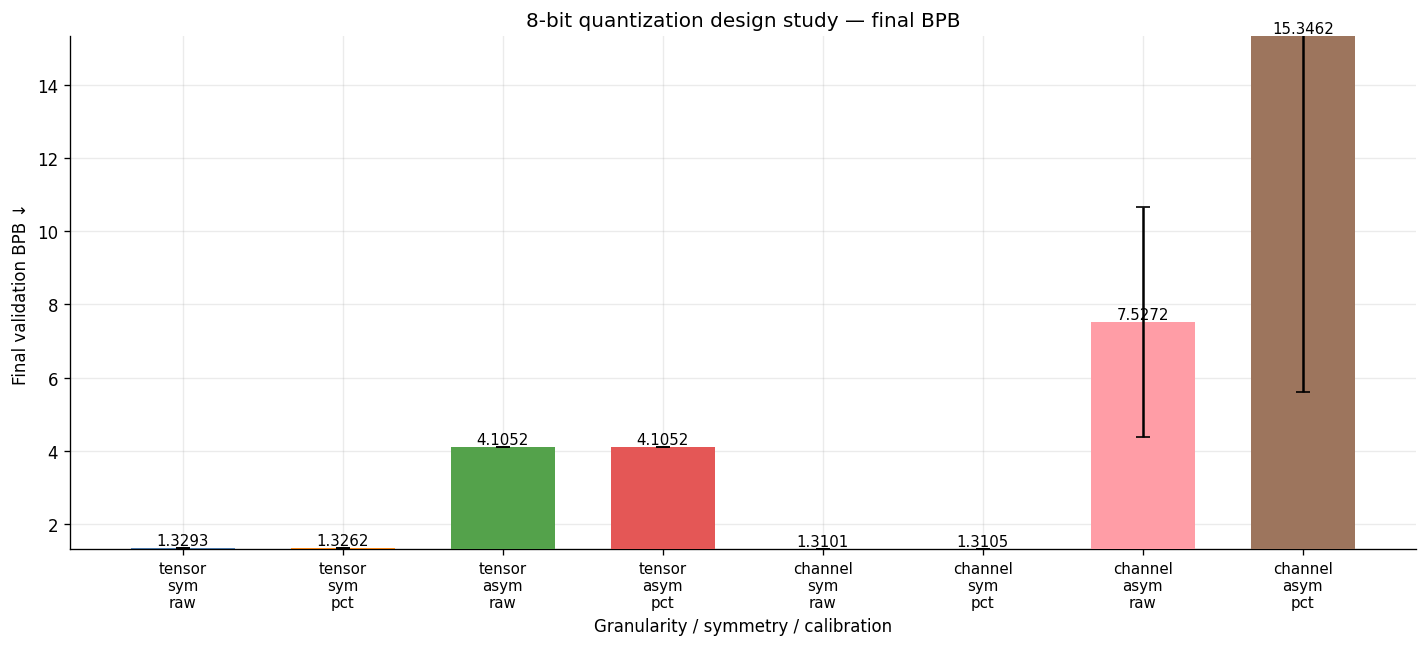

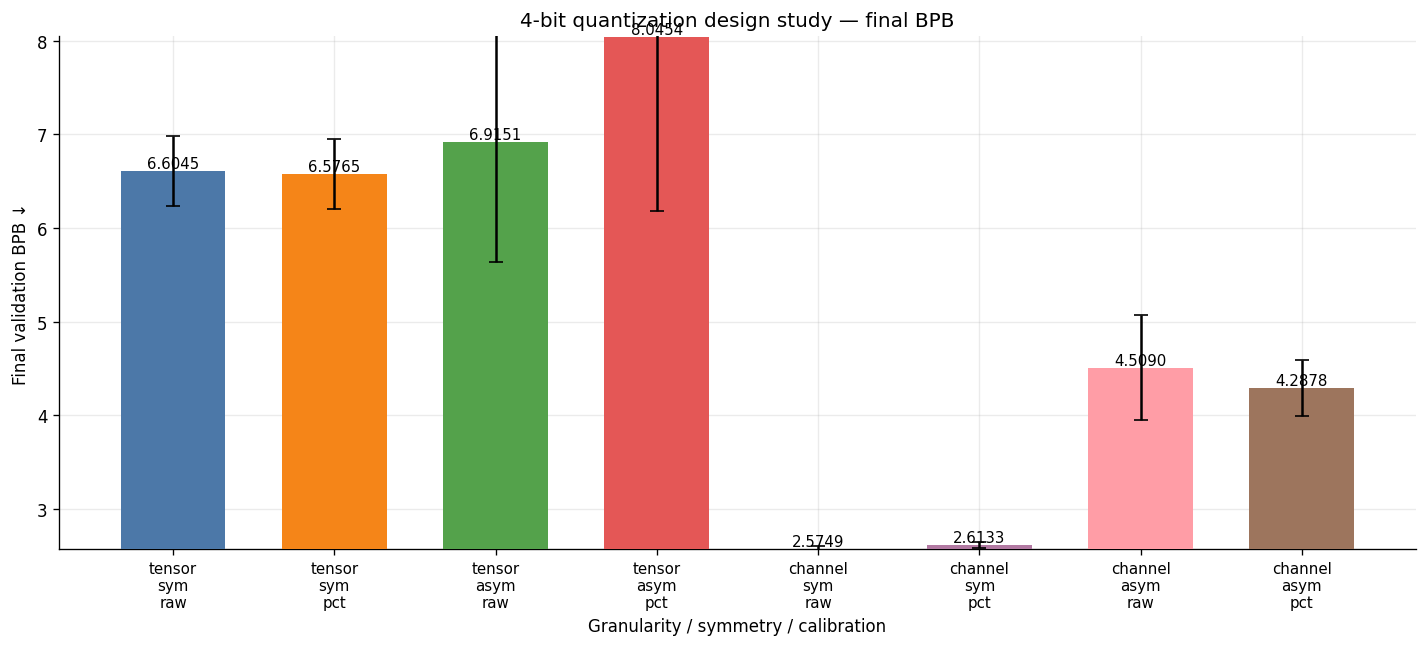

In [9]:
plot_df = agg.copy()
plot_df["short_label"] = (
    plot_df["granularity"].map({"per_tensor": "tensor", "per_channel": "channel"}) + "\n" +
    plot_df["symmetry"].map({"symmetric": "sym", "asymmetric": "asym"}) + "\n" +
    plot_df["calibration"].map({"uncalibrated": "raw", "percentile": "pct"})
)

for bits in BITS_ORDER:
    sub = plot_df[plot_df["bits"] == bits].reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(12, 5.5))
    x = np.arange(len(sub))
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(sub))]

    ax.bar(
        x,
        sub["final_val_bpb_mean"],
        yerr=sub["final_val_bpb_std"],
        capsize=4,
        color=colors,
        width=0.65,
        zorder=3,
    )

    for i, val in enumerate(sub["final_val_bpb_mean"]):
        ax.text(i, val + 0.0004, f"{val:.4f}", ha="center", va="bottom", fontsize=9, rotation=0)

    ax.set_xticks(x)
    ax.set_xticklabels(sub["short_label"], fontsize=9)
    ax.set_ylabel("Final validation BPB ↓")
    ax.set_xlabel("Granularity / symmetry / calibration")
    ax.set_title(f"{bits}-bit quantization design study — final BPB")
    ymin = sub["final_val_bpb_mean"].min() - 0.003
    ymax = sub["final_val_bpb_mean"].max() + 0.006
    ax.set_ylim(ymin, ymax)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"final_bpb_{bits}bit_by_config.png", bbox_inches="tight")
    plt.show()

## Plot: compressed file size by configuration

This checks whether the design choices materially affect artifact size, not just BPB.

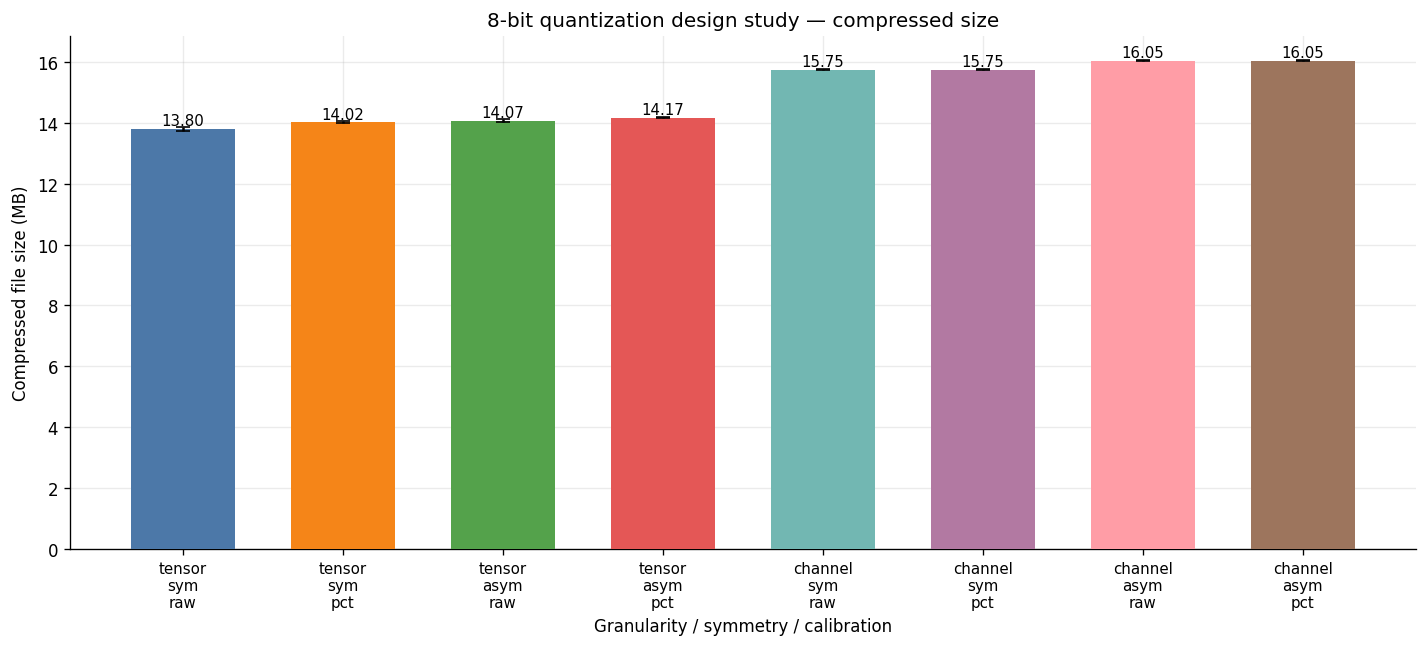

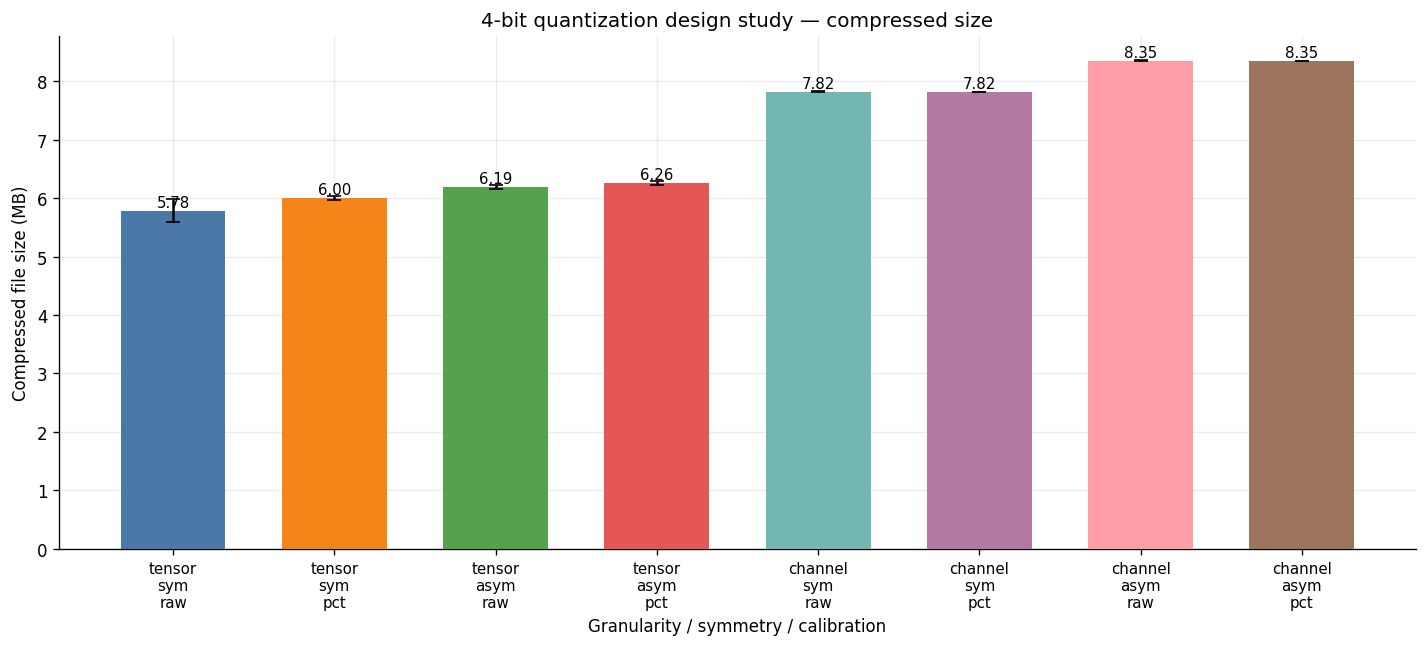

In [10]:
for bits in BITS_ORDER:
    sub = plot_df[plot_df["bits"] == bits].reset_index(drop=True)
    if sub["quant_file_MB_mean"].isna().all():
        print(f"Skipping {bits}-bit size plot: quant_file_MB not found in summaries")
        continue

    fig, ax = plt.subplots(figsize=(12, 5.5))
    x = np.arange(len(sub))
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(sub))]

    ax.bar(
        x,
        sub["quant_file_MB_mean"],
        yerr=sub["quant_file_MB_std"],
        capsize=4,
        color=colors,
        width=0.65,
        zorder=3,
    )

    for i, val in enumerate(sub["quant_file_MB_mean"]):
        if pd.notna(val):
            ax.text(i, val + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(sub["short_label"], fontsize=9)
    ax.set_ylabel("Compressed file size (MB)")
    ax.set_xlabel("Granularity / symmetry / calibration")
    ax.set_title(f"{bits}-bit quantization design study — compressed size")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"compressed_size_{bits}bit_by_config.png", bbox_inches="tight")
    plt.show()

## Main effects

This section averages across the other factors to estimate the overall effect of each design choice.

Interpretation: lower mean BPB is better.

In [11]:
def main_effect_table(factor):
    tbl = (
        agg.groupby(["bits", factor], as_index=False)
           .agg(
               mean_bpb=("final_val_bpb_mean", "mean"),
               std_across_configs=("final_val_bpb_mean", "std"),
               mean_size_MB=("quant_file_MB_mean", "mean"),
           )
           .sort_values(["bits", factor])
    )
    return tbl

for factor in ["granularity", "symmetry", "calibration"]:
    print("=" * 80)
    print(f"Main effect: {factor}")
    print("=" * 80)
    display(main_effect_table(factor))

Main effect: granularity


,bits,granularity,mean_bpb,std_across_configs,mean_size_MB
0,4,per_channel,3.496263,1.045753,8.082108
1,4,per_tensor,7.035365,0.690642,6.058515
2,8,per_channel,6.373514,6.661126,15.898355
3,8,per_tensor,2.716475,1.603571,14.016172


Main effect: symmetry


,bits,symmetry,mean_bpb,std_across_configs,mean_size_MB
0,4,asymmetric,5.939339,1.840378,7.286236
1,4,symmetric,4.592289,2.307392,6.854387
2,8,asymmetric,7.770958,5.301539,15.082489
3,8,symmetric,1.319031,0.010137,14.832038


Main effect: calibration


,bits,calibration,mean_bpb,std_across_configs,mean_size_MB
0,4,percentile,5.380776,2.407167,7.106004
1,4,uncalibrated,5.150852,2.022635,7.034620
2,8,percentile,5.522030,6.679901,14.996526
3,8,uncalibrated,3.567959,2.948105,14.918001


## Pairwise deltas

These tables compute paired differences while holding the other factors fixed.

Examples:
- `per_channel - per_tensor`: negative means per-channel is better.
- `asymmetric - symmetric`: negative means asymmetric is better.
- `percentile - uncalibrated`: negative means percentile clipping is better.

In [12]:
def paired_delta(index_cols, factor_col, a, b, metric="final_val_bpb_mean"):
    piv = agg.pivot_table(index=index_cols, columns=factor_col, values=metric)
    piv[f"{b} - {a}"] = piv[b] - piv[a]
    return piv.reset_index()

print("Per-channel vs per-tensor: final_val_bpb_mean")
delta_gran = paired_delta(["bits", "symmetry", "calibration"], "granularity", "per_tensor", "per_channel")
display(delta_gran)

print("\nAsymmetric vs symmetric: final_val_bpb_mean")
delta_sym = paired_delta(["bits", "granularity", "calibration"], "symmetry", "symmetric", "asymmetric")
display(delta_sym)

print("\nPercentile vs uncalibrated: final_val_bpb_mean")
delta_cal = paired_delta(["bits", "granularity", "symmetry"], "calibration", "uncalibrated", "percentile")
display(delta_cal)

# Save deltas
delta_gran.to_csv(OUT_DIR / "delta_per_channel_minus_per_tensor.csv", index=False)
delta_sym.to_csv(OUT_DIR / "delta_asymmetric_minus_symmetric.csv", index=False)
delta_cal.to_csv(OUT_DIR / "delta_percentile_minus_uncalibrated.csv", index=False)

Per-channel vs per-tensor: final_val_bpb_mean


granularity,bits,symmetry,calibration,per_channel,per_tensor,per_channel - per_tensor
0,4,asymmetric,percentile,4.287840,8.045439,-3.757598
1,4,asymmetric,uncalibrated,4.509013,6.915064,-2.406051
2,4,symmetric,percentile,2.613341,6.576486,-3.963145
3,4,symmetric,uncalibrated,2.574858,6.604472,-4.029614
4,8,asymmetric,percentile,15.346187,4.105208,11.240979
5,8,asymmetric,uncalibrated,7.527228,4.105208,3.422020
6,8,symmetric,percentile,1.310513,1.326211,-0.015698
7,8,symmetric,uncalibrated,1.310128,1.329274,-0.019146



Asymmetric vs symmetric: final_val_bpb_mean


symmetry,bits,granularity,calibration,asymmetric,symmetric,asymmetric - symmetric
0,4,per_channel,percentile,4.287840,2.613341,1.674499
1,4,per_channel,uncalibrated,4.509013,2.574858,1.934155
2,4,per_tensor,percentile,8.045439,6.576486,1.468953
3,4,per_tensor,uncalibrated,6.915064,6.604472,0.310592
4,8,per_channel,percentile,15.346187,1.310513,14.035674
5,8,per_channel,uncalibrated,7.527228,1.310128,6.217101
6,8,per_tensor,percentile,4.105208,1.326211,2.778997
7,8,per_tensor,uncalibrated,4.105208,1.329274,2.775934



Percentile vs uncalibrated: final_val_bpb_mean


calibration,bits,granularity,symmetry,percentile,uncalibrated,percentile - uncalibrated
0,4,per_channel,asymmetric,4.287840,4.509013,-0.221172
1,4,per_channel,symmetric,2.613341,2.574858,0.038483
2,4,per_tensor,asymmetric,8.045439,6.915064,1.130375
3,4,per_tensor,symmetric,6.576486,6.604472,-0.027986
4,8,per_channel,asymmetric,15.346187,7.527228,7.818959
5,8,per_channel,symmetric,1.310513,1.310128,0.000385
6,8,per_tensor,asymmetric,4.105208,4.105208,0.000000
7,8,per_tensor,symmetric,1.326211,1.329274,-0.003063


## Interaction plot

This plot helps show whether the best choice changes between 8-bit and 4-bit.

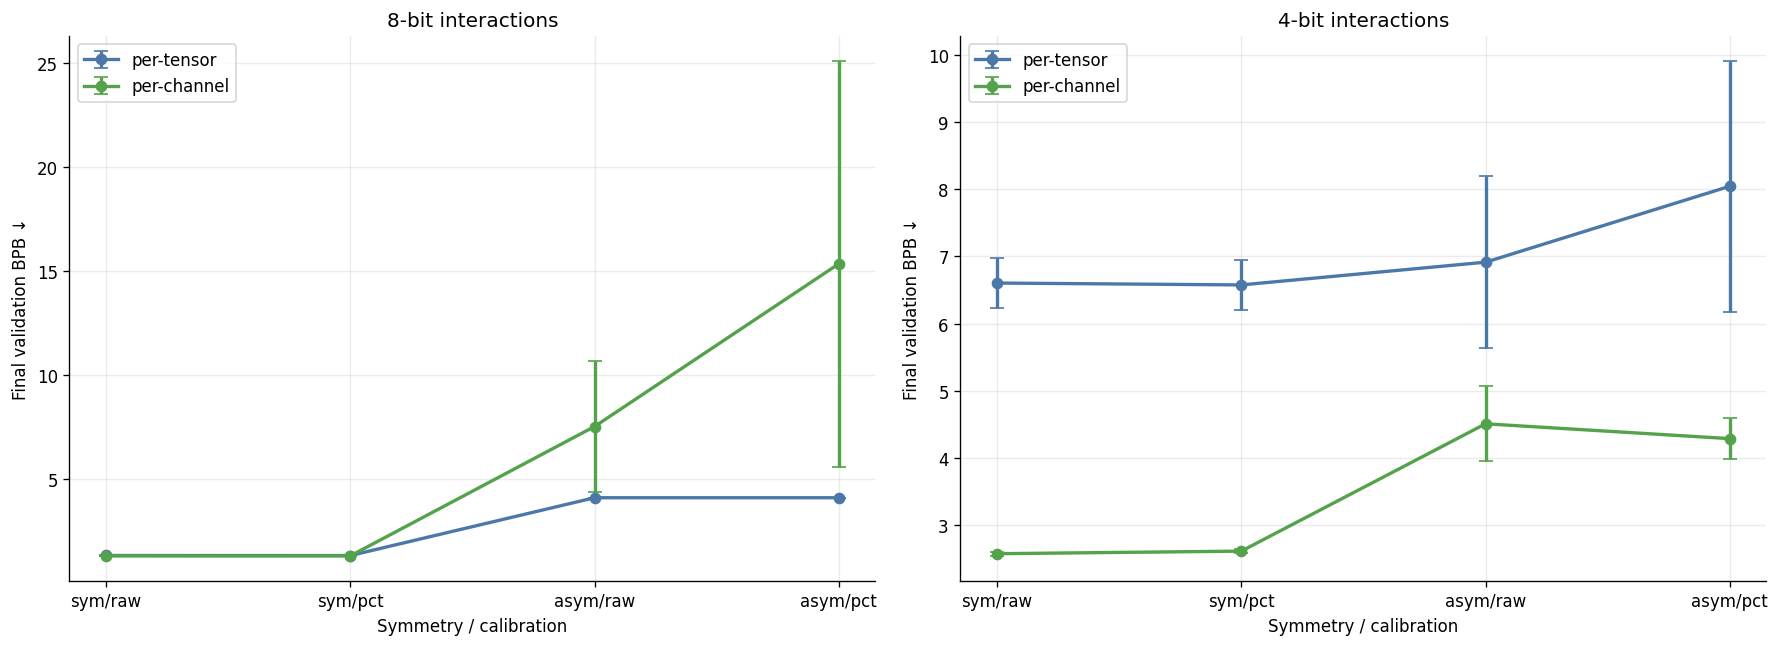

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=False)

for ax, bits in zip(axes, BITS_ORDER):
    sub = agg[agg["bits"] == bits].copy()
    x_labels = ["sym/raw", "sym/pct", "asym/raw", "asym/pct"]
    x = np.arange(len(x_labels))

    for gran, color in zip(GRAN_ORDER, [PALETTE[0], PALETTE[2]]):
        vals = []
        errs = []
        for sym, cal in [("symmetric", "uncalibrated"), ("symmetric", "percentile"), ("asymmetric", "uncalibrated"), ("asymmetric", "percentile")]:
            row = sub[(sub["granularity"] == gran) & (sub["symmetry"] == sym) & (sub["calibration"] == cal)]
            vals.append(row["final_val_bpb_mean"].iloc[0])
            errs.append(row["final_val_bpb_std"].iloc[0])
        ax.errorbar(x, vals, yerr=errs, marker="o", linewidth=2, capsize=4, label=DISPLAY_LABELS[gran], color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Final validation BPB ↓")
    ax.set_xlabel("Symmetry / calibration")
    ax.set_title(f"{bits}-bit interactions")
    ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "interaction_granularity_symmetry_calibration.png", bbox_inches="tight")
plt.show()

## Summary table

In [15]:
report = agg[[
    "bits", "granularity", "symmetry", "calibration", "n_seeds",
    "final_val_bpb_mean", "final_val_bpb_std",
    "delta_bpb_mean", "quant_file_MB_mean"
]].copy()

report = report.sort_values(["bits", "granularity", "symmetry", "calibration"]).reset_index(drop=True)
report["granularity"] = report["granularity"].map(DISPLAY_LABELS)
report["symmetry"] = report["symmetry"].map(DISPLAY_LABELS)
report["calibration"] = report["calibration"].map(DISPLAY_LABELS)

report_display = report.copy()
report_display["final_val_bpb"] = report_display.apply(
    lambda r: f"{r['final_val_bpb_mean']:.4f} ± {r['final_val_bpb_std']:.4f}", axis=1
)
report_display["delta_bpb"] = report_display["delta_bpb_mean"].map(lambda x: f"{x:+.4f}" if pd.notna(x) else "—")
report_display["size_MB"] = report_display["quant_file_MB_mean"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")

report_display = report_display[[
    "bits", "granularity", "symmetry", "calibration", "n_seeds", "final_val_bpb", "delta_bpb", "size_MB"
]]

report_display.to_csv(OUT_DIR / "report_ready_quant_design_table.csv", index=False)
report_display.to_markdown(OUT_DIR / "report_ready_quant_design_table.md", index=False)
report_display

,bits,granularity,symmetry,calibration,n_seeds,final_val_bpb,delta_bpb,size_MB
0,4,per-channel,asymmetric,percentile-clipped,3,4.2878 ± 0.3011,+2.9812,8.35
1,4,per-channel,asymmetric,uncalibrated,3,4.5090 ± 0.5575,+3.2027,8.35
2,4,per-channel,symmetric,percentile-clipped,3,2.6133 ± 0.0333,+1.3068,7.82
3,4,per-channel,symmetric,uncalibrated,3,2.5749 ± 0.0328,+1.2683,7.82
4,4,per-tensor,asymmetric,percentile-clipped,3,8.0454 ± 1.8683,+6.7390,6.26
5,4,per-tensor,asymmetric,uncalibrated,3,6.9151 ± 1.2805,+5.6084,6.19
6,4,per-tensor,symmetric,percentile-clipped,3,6.5765 ± 0.3778,+5.2701,6.00
7,4,per-tensor,symmetric,uncalibrated,3,6.6045 ± 0.3734,+5.2981,5.78
8,8,per-channel,asymmetric,percentile-clipped,3,15.3462 ± 9.7565,+14.0397,16.05
9,8,per-channel,asymmetric,uncalibrated,3,7.5272 ± 3.1482,+6.2211,16.05


## Quantization Design Study Results

**Best overall configuration**

- **8-bit, per-channel, symmetric, uncalibrated**
- `final_val_bpb = 1.310128 ± 0.001125`

**Worst overall configuration**

- **8-bit, per-channel, asymmetric, percentile-clipped**
- `final_val_bpb = 15.346187 ± 9.756486`

**Average paired effects**

*Negative is better.*

| Comparison | Effect on BPB |
|---|---:|
| Per-channel − per-tensor | `+0.058968` |
| Asymmetric − symmetric | `+3.899488` |
| Percentile − raw | `+1.091997` |


*In the basic quantization design study, we evaluated bitwidth, granularity, symmetry, and clipping-based calibration over three seeds. The best configuration was **8-bit per-channel symmetric with uncalibrated**, achieving **1.3101 BPB** on average. The paired-delta tables above isolate the contribution of each design choice.*